In [12]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib widget

In [143]:
# Pulse-level waveform description
def Omega_x(t, args):
    for item, pulse_specs in args.items():
        if item == 'clock':
            continue
        if t <= pulse_specs['start'] or t >= (pulse_specs['start'] + pulse_specs['tg']):
            continue
        else:
            t_local = t - pulse_specs['start']
            return pulse_specs['A'] * (np.exp(-(t_local-pulse_specs['tg']/2)**2/(2*pulse_specs['sigma']**2)) - np.exp(-pulse_specs['tg']**2/(8*pulse_specs['sigma']**2))) \
                        / (1-np.exp(-pulse_specs['tg']**2/(8*pulse_specs['sigma']**2))) # normalization part, truncated Gaussian amplitude will be pulse_specs['A]
    return 0

def Omega_y(t, args):
    for item, pulse_specs in args.items():
        if item == 'clock':
            continue
        if t <= pulse_specs['start'] or t >= (pulse_specs['start'] + pulse_specs['tg']):
            continue
        else:
            t_local = t - pulse_specs['start']
            tg = pulse_specs['tg']
            sigma = pulse_specs['sigma']
            A = pulse_specs['A']

            # Gaussian normalization
            norm = 1 - np.exp(-tg**2 / (8 * sigma**2))
            gauss = np.exp(-(t_local - tg/2)**2 / (2 * sigma**2))
            offset = np.exp(-tg**2 / (8 * sigma**2))

            G = A * (gauss - offset) / norm
            dG = -A * (t_local - tg/2) / sigma**2 * gauss / norm

            # Raised-cosine window
            w = 0.5 * (1 - np.cos(2 * np.pi * t_local / tg))
            dw = (np.pi / tg) * np.sin(2 * np.pi * t_local / tg)
            result = dG * w + G * dw
            result_scaled = pulse_specs['beta']*result
            return result_scaled
    return 0

def Omega_y_old(t, args):
    beta = args['beta']
    A = args['A']
    tg = args['tg']
    sigma = args['sigma']
    
    if 0 <= t <= tg:
        # window = 1*np.sin(np.pi * t / tg)**2
        window = 1
        gauss = np.exp(-(t - tg/2)**2 / (2 * sigma**2))
        norm = 1 - np.exp(-tg**2 / (8 * sigma**2))
        return -(beta/(2*np.pi*0.307)) * A * (t - tg/2) * gauss * window / (sigma**2 * norm)
    else:
        return 0.0

def add_pulse(pulse_train, pulse_name, start, tg, sigma, A, beta):
    pulse_train[pulse_name] = {'start': start, 'tg': tg, 'sigma': sigma, 'A': A, 'beta': beta}
    pulse_train['clock'] += tg

In [144]:
ratio = 100
sampling_freq = 40
omega_d = 4.678
anharmonicity = 0.3071
times = np.arange(0, 20*ratio, 1/sampling_freq)

In [152]:
args_gaussian = {'clock': 0}
add_pulse(args_gaussian, pulse_name='Gaussian', start=args_gaussian['clock'], tg=20, sigma=20/4, A=1, beta=0)

args_drag = {'clock': 0}
add_pulse(args_drag, pulse_name='DRAG', start=args_drag['clock'], tg=20, sigma=20/4, A=1, beta=0.403/(2*np.pi*anharmonicity))

In [158]:
omega_x_gaussian = [Omega_x(t, args_gaussian) for t in times]
omega_y_gaussian = [Omega_y(t, args_gaussian) for t in times]
signal_gaussian = [Omega_x(t, args_gaussian)*np.cos(2*np.pi*omega_d*t)+Omega_y(t, args_gaussian)*np.sin(2*np.pi*omega_d*t) for t in times]

omega_x_drag = [Omega_x(t, args_drag) for t in times]
omega_y_drag = [Omega_y(t, args_drag) for t in times]
signal_drag = [Omega_x(t, args_drag)*np.cos(2*np.pi*omega_d*t)+Omega_y(t, args_drag)*np.sin(2*np.pi*omega_d*t) for t in times]

args_leakage = {'A': 1, 'tg': 20, 'sigma': 5, 'beta': 0.403} 
omega_x_leakage = [Omega_x(t, args_gaussian) for t in times]
omega_y_leakage = [Omega_y_old(t, args_leakage) for t in times]
signal_leakage = [Omega_x(t, args_gaussian)*np.cos(2*np.pi*omega_d*t)+Omega_y_old(t, args_leakage)*np.sin(2*np.pi*omega_d*t) for t in times]

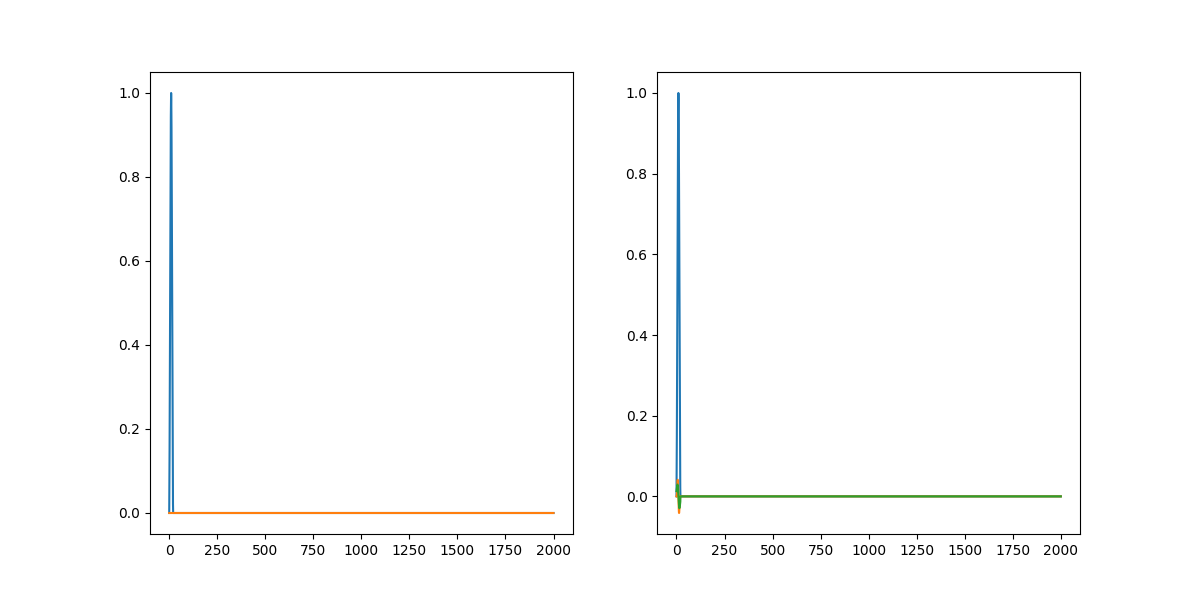

In [159]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))

axes[0].plot(times, omega_x_gaussian)
axes[0].plot(times, omega_y_gaussian)

axes[1].plot(times, omega_x_drag)
axes[1].plot(times, omega_y_drag)
axes[1].plot(times, omega_y_leakage)

In [160]:
def myfftshift(signal, sampling_freq):
    fft_signal = np.fft.fftshift(np.fft.fft(signal))
    freqs = np.fft.fftshift(np.fft.fftfreq(fft_signal.size, d=1/sampling_freq))
    magnitude = np.abs(fft_signal)/fft_signal.size
    magnitude[1:-1] *= 2
    
    return freqs, magnitude

In [161]:
freqs, magnitude_gaussian = myfftshift(signal_gaussian, sampling_freq)
freqs, magnitude_drag = myfftshift(signal_leakage, sampling_freq)

freqs = freqs-omega_d
freqs = freqs/anharmonicity

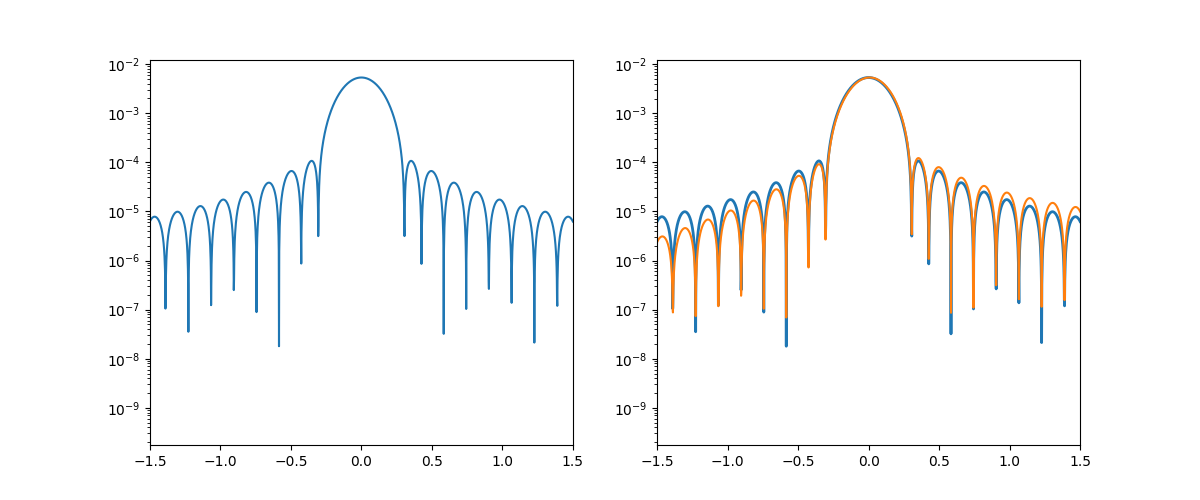

In [162]:
fig, axes = plt.subplots(ncols=2, figsize=(12,5))

axes[0].plot(freqs, magnitude_gaussian)
axes[1].plot(freqs, magnitude_gaussian, lw=2)
axes[1].plot(freqs, magnitude_drag, color='tab:orange')

for ax in axes:
    ax.set_xlim(-1.5, 1.5)
    ax.set_yscale('log')